In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [2]:
#Loading Cleaned Data
print("Loading cleaned data...")
df = pd.read_csv('cleaned_data_for_python.csv')
df['date'] = pd.to_datetime(df['date'])

#Defining platforms and transfer amount
platforms = ['paypal', 'wise', 'revolut']
TRANSFER_AMOUNT = 1000

print(f"Total observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Currency pairs: {df['slug'].unique().tolist()}")

Loading cleaned data...
Total observations: 3845
Date range: 2015-01-01 00:00:00 to 2019-12-31 00:00:00
Currency pairs: ['EUR/USD', 'EUR/GBP', 'EUR/JPY']




Exchange Rate Trends Over 5 Years


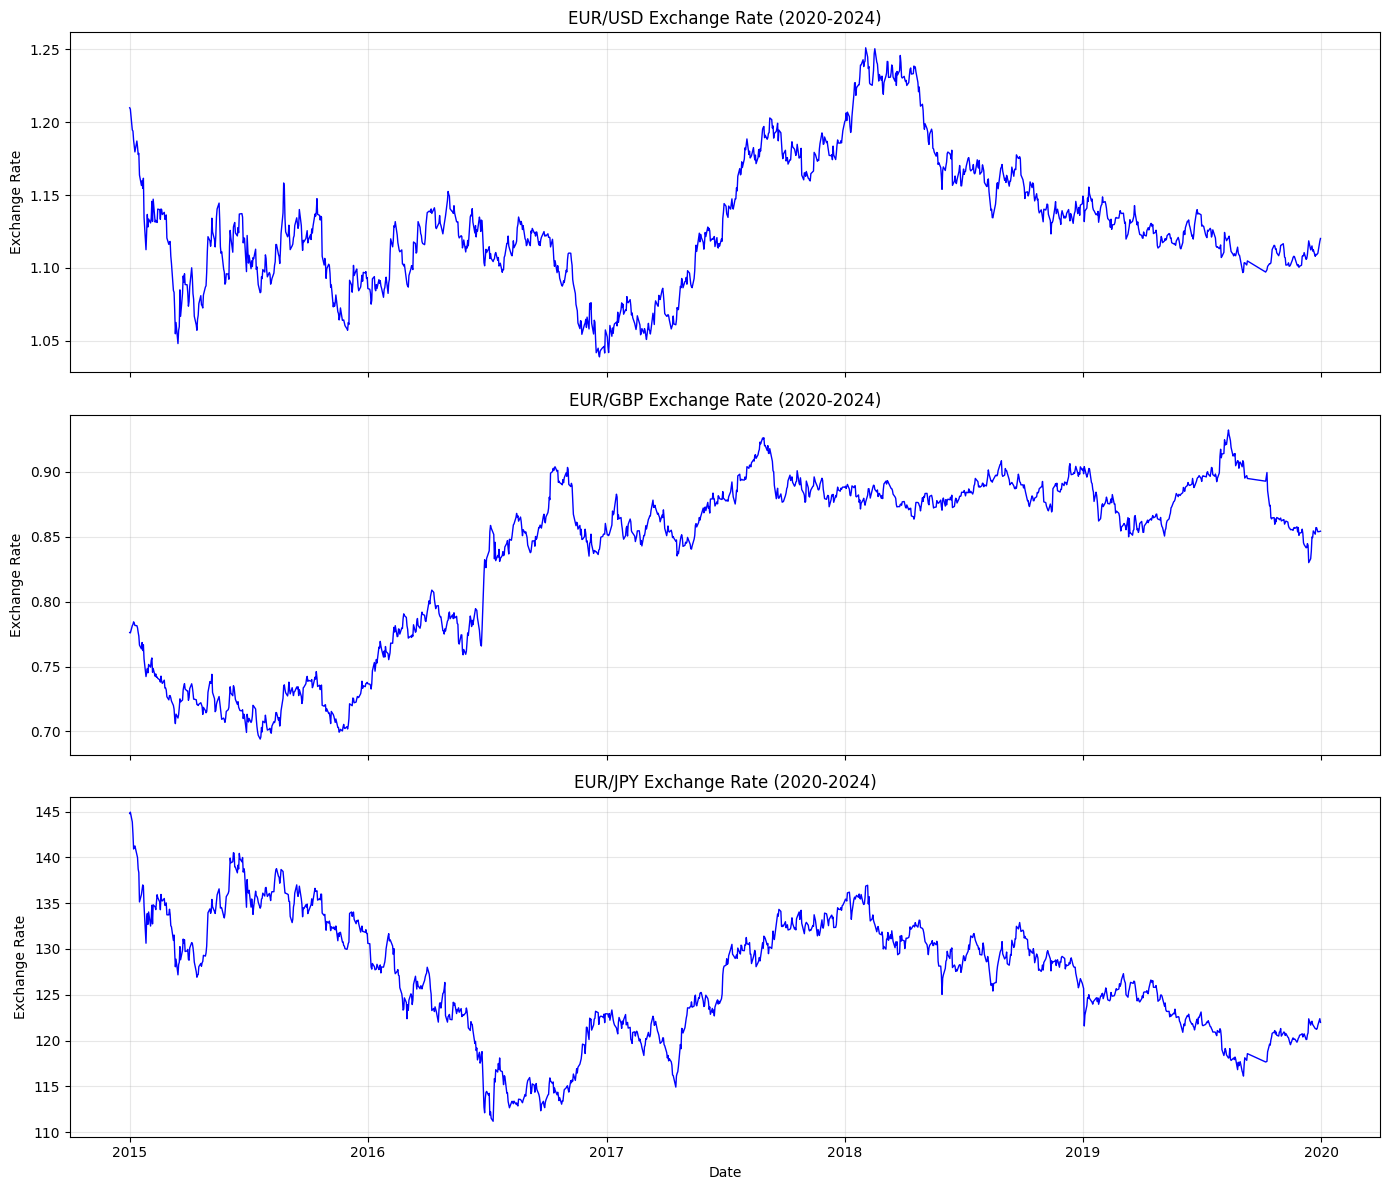

In [3]:
#Plotting Exchange Rate Trends (5 years)
print("\n")
print("Exchange Rate Trends Over 5 Years")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
currency_pairs = df['slug'].unique()

for idx, currency in enumerate(currency_pairs):
    subset = df[df['slug'] == currency]
    axes[idx].plot(subset['date'], subset['close'], linewidth=1, color='blue')
    axes[idx].set_title(f'{currency} Exchange Rate (2020-2024)', fontsize=12)
    axes[idx].set_ylabel('Exchange Rate')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('long_term_trends.pdf', dpi=300)



Seasonal Patterns by Month


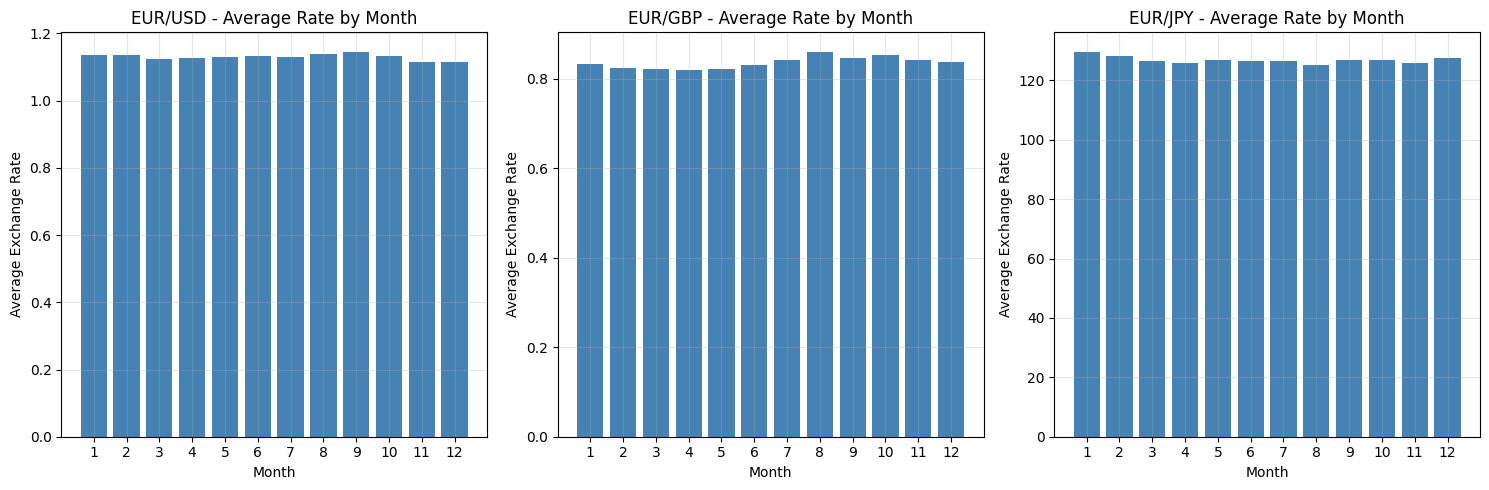

In [4]:
#Seasonal Patterns by Month
print("\n")
print("Seasonal Patterns by Month")

#Creating monthly average exchange rates
monthly_avg = df.groupby(['slug', 'month'])['close'].mean().reset_index()

#Plotting seasonal patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, currency in enumerate(currency_pairs):
    subset = monthly_avg[monthly_avg['slug'] == currency]
    axes[idx].bar(subset['month'], subset['close'], color='steelblue')
    axes[idx].set_title(f'{currency} - Average Rate by Month')
    axes[idx].set_xlabel('Month')
    axes[idx].set_ylabel('Average Exchange Rate')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seasonal_patterns.pdf', dpi=300)

#Seasonal analysis table
seasonal_table = df.groupby(['slug', 'month']).agg({
    'close': ['mean', 'min', 'max', 'std']
}).round(4)
seasonal_table.to_csv('seasonal_analysis_table.csv')



Day-of-Week Effects


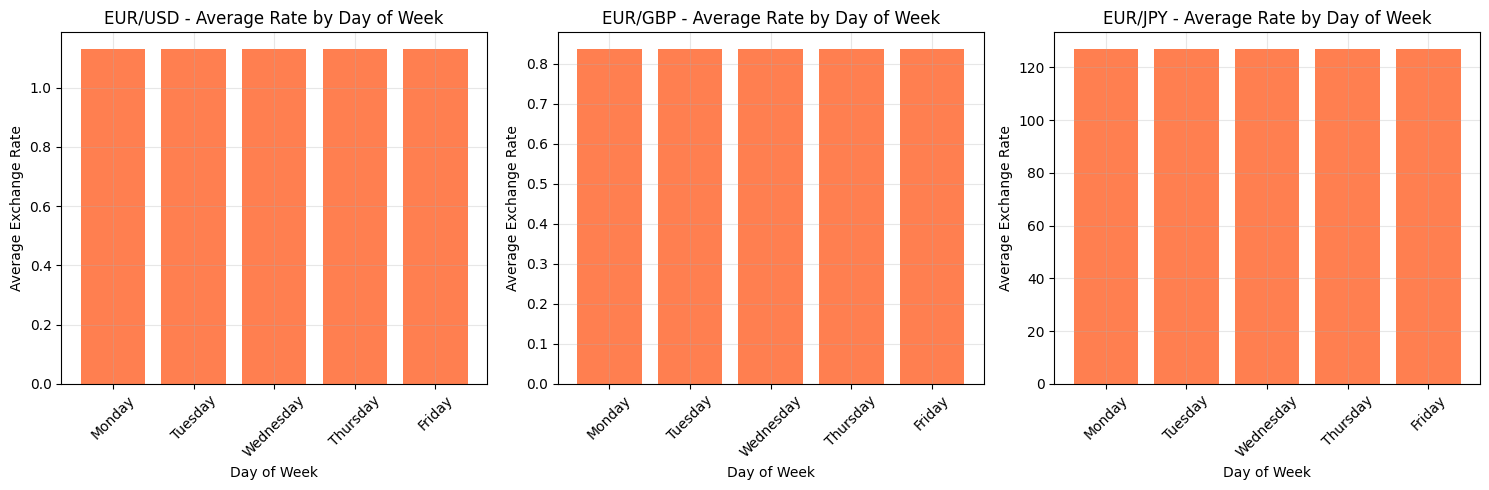

In [5]:
#Day-of-Week Effects
print("\n")
print("Day-of-Week Effects")

# Creating weekday average exchange rates
weekday_avg = df.groupby(['slug', 'day_name'])['close'].mean().reset_index()
# Ensuring proper order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg['day_name'] = pd.Categorical(weekday_avg['day_name'], categories=day_order, ordered=True)
weekday_avg = weekday_avg.sort_values(['slug', 'day_name'])

#Plotting day-of-week effects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, currency in enumerate(currency_pairs):
    subset = weekday_avg[weekday_avg['slug'] == currency]
    axes[idx].bar(subset['day_name'], subset['close'], color='coral')
    axes[idx].set_title(f'{currency} - Average Rate by Day of Week')
    axes[idx].set_xlabel('Day of Week')
    axes[idx].set_ylabel('Average Exchange Rate')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day_of_week_effects.pdf', dpi=300)

#Day-of-week analysis table
weekday_table = df.groupby(['slug', 'day_name', 'day_of_week']).agg({
    'close': ['mean', 'std']
}).round(4)
weekday_table.to_csv('day_of_week_analysis_table.csv')

In [6]:
#Best and Worst Months for Payments

print("\n")
print("Best and Worst Months for Payments")

best_worst_months = []

for currency in currency_pairs:
    subset = df[df['slug'] == currency]
    # Calculating average final cost for Revolut (most cost-effective for small transfers)
    monthly_cost = subset.groupby('month')['revolut_final_cost'].mean().reset_index()

    best_month = monthly_cost.loc[monthly_cost['revolut_final_cost'].idxmin(), 'month']
    worst_month = monthly_cost.loc[monthly_cost['revolut_final_cost'].idxmax(), 'month']

    best_worst_months.append({
        'Currency': currency,
        'Best Month': best_month,
        'Worst Month': worst_month,
        'Best Month Cost': monthly_cost['revolut_final_cost'].min(),
        'Worst Month Cost': monthly_cost['revolut_final_cost'].max(),
        'Difference': monthly_cost['revolut_final_cost'].max() - monthly_cost['revolut_final_cost'].min()
    })

best_worst_df = pd.DataFrame(best_worst_months)
best_worst_df.to_csv('best_worst_months.csv', index=False)




Best and Worst Months for Payments


In [7]:
#Calculating Average Savings from Timing Optimization

print("\n")
print("Average Savings from Timing Optimization")

# Calculating potential savings by choosing the best month vs average
savings_summary = []

for currency in currency_pairs:
    subset = df[df['slug'] == currency]

    # For Revolut (most relevant for small users)
    avg_cost = subset['revolut_final_cost'].mean()
    monthly_avg = subset.groupby('month')['revolut_final_cost'].mean()
    best_month_cost = monthly_avg.min()

    savings = avg_cost - best_month_cost
    savings_pct = (savings / avg_cost) * 100

    savings_summary.append({
        'Currency': currency,
        'Average Cost (€)': round(avg_cost, 2),
        'Best Month Cost (€)': round(best_month_cost, 2),
        'Potential Savings (€)': round(savings, 2),
        'Savings %': round(savings_pct, 2)
    })

savings_df = pd.DataFrame(savings_summary)
savings_df.to_csv('savings_estimate_table.csv', index=False)



Average Savings from Timing Optimization


In [8]:
#Simple Recommendations for Small Businesses

print("\n")
print("Writing Simple Recommendations")

recommendations = f"""

Date: {datetime.now().strftime('%B %d, %Y')}

1. CHOOSE THE RIGHT PLATFORM

Based on a {TRANSFER_AMOUNT:,}€ transfer:

| Platform | Average Final Cost | Markup | Best For |
|----------|-------------------|--------|----------|
| PayPal   | €{df['paypal_final_cost'].mean():.2f} | 3.00% | Convenience only |
| Wise     | €{df['wise_final_cost'].mean():.2f} | 0% | Transparent, larger amounts |
| Revolut  | €{df['revolut_final_cost'].mean():.2f} | 0% (weekday) | Small amounts, weekday payments |

Key Insight: On average, Wise saves you €{df['paypal_final_cost'].mean() - df['wise_final_cost'].mean():.2f} per €1,000 transfer compared to PayPal.


2. CHOOSE THE RIGHT TIME

Best Months to Pay (EUR to Foreign Currencies):
"""

#Add best months
for _, row in best_worst_df.iterrows():
    recommendations += f"  • {row['Currency']}: Month {row['Best Month']:.0f} (save up to €{row['Difference']:.2f} vs worst month)\n"

recommendations += f"""
Key Insight: Paying in the best month saves an average of €{savings_df['Potential Savings (€)'].mean():.2f} per €1,000 transfer.


3. AVOID WEEKENDS

Revolut charges a 1% markup on weekends. For a €1,000 transfer, that's €10 extra.

Key Insight: Always make payments on weekdays (Monday-Friday) to avoid weekend markups.


4. QUICK SUMMARY

Use Wise or Revolut (not PayPal) for better rates
Pay on weekdays (avoid Saturday/Sunday)
Check the best month for your specific currency pair
Consider bundling multiple payments into one larger transfer


5. RECOMMENDED PAYMENT CALENDAR

Based on your analysis:

For EUR/USD: Best to pay in Month {best_worst_df[best_worst_df['Currency'] == 'EUR/USD']['Best Month'].values[0] if 'EUR/USD' in best_worst_df['Currency'].values else 'N/A'}
For EUR/GBP: Best to pay in Month {best_worst_df[best_worst_df['Currency'] == 'EUR/GBP']['Best Month'].values[0] if 'EUR/GBP' in best_worst_df['Currency'].values else 'N/A'}
For EUR/JPY: Best to pay in Month {best_worst_df[best_worst_df['Currency'] == 'EUR/JPY']['Best Month'].values[0] if 'EUR/JPY' in best_worst_df['Currency'].values else 'N/A'}

"""

#Save as text file
with open('How_to_Save_Money_on_Cross_Border_Payments.txt', 'w') as f:
    f.write(recommendations)



Writing Simple Recommendations
